In [7]:
import numpy as np
import scipy
from scipy.signal import welch, hilbert
from scipy.stats import skew, kurtosis
from sklearn.base import BaseEstimator, TransformerMixin

class CSPFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Combined CSP + Multi-domain feature extraction for EEG
    """
    
    def __init__(self, n_components=6, freq_bands=None, sfreq=250):
        self.n_components = n_components
        self.sfreq = sfreq
        self.W = None  # CSP filters
        self.freq_bands = freq_bands or {
            'delta': (0.5, 4),
            'theta': (4, 8), 
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 50)
        }
    
    def fit(self, X, y):
        """
        Fit CSP filters
        
        Parameters:
        -----------
        X : ndarray, shape (n_trials, n_channels, n_samples)
        y : ndarray, shape (n_trials,)
            Class labels (0 or 1)
        """
        # Separate classes
        X_class0 = X[y == 0]
        X_class1 = X[y == 1]
        
        # Compute covariance matrices
        C0 = self._covariance(X_class0)
        C1 = self._covariance(X_class1)
        
        # Solve generalized eigenvalue problem
        eigenvals, eigenvecs = scipy.linalg.eigh(C1, C0 + C1)
        
        # Sort by eigenvalues
        idx = np.argsort(eigenvals)[::-1]
        eigenvecs = eigenvecs[:, idx]
        
        # Select CSP filters (first and last n_components/2)
        self.W = np.concatenate([
            eigenvecs[:, :self.n_components//2].T,
            eigenvecs[:, -self.n_components//2:].T
        ])
        
        return self
    
    def _covariance(self, X):
        """Compute normalized covariance matrix"""
        n_trials, n_channels, n_samples = X.shape
        cov = np.zeros((n_channels, n_channels))
        
        for trial in range(n_trials):
            trial_data = X[trial]
            trial_cov = np.cov(trial_data)
            # Normalize by trace
            cov += trial_cov / np.trace(trial_cov)
            
        return cov / n_trials
    
    def extract_csp_features(self, X):
        """Extract CSP features"""
        if self.W is None:
            raise ValueError("CSP not fitted")
        
        n_trials = X.shape[0]
        csp_features = np.zeros((n_trials, self.n_components))
        
        for trial in range(n_trials):
            # Apply CSP filters
            filtered = np.dot(self.W, X[trial])
            # Compute log variance
            csp_features[trial] = np.log(np.var(filtered, axis=1))
            
        return csp_features
    
    def extract_time_features(self, X):
        """Extract time-domain features"""
        n_trials, n_channels, n_samples = X.shape
        
        features = []
        for trial in range(n_trials):
            trial_features = []
            
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                
                # Statistical features
                trial_features.extend([
                    np.mean(signal),          # Mean
                    np.std(signal),           # Standard deviation
                    np.var(signal),           # Variance
                    skew(signal),             # Skewness
                    kurtosis(signal),         # Kurtosis
                    np.max(signal),           # Maximum
                    np.min(signal),           # Minimum
                    np.ptp(signal),           # Peak-to-peak
                    np.median(signal),        # Median
                    np.mean(np.abs(signal)),  # Mean absolute value
                ])
                
                # Zero crossing rate
                zero_crossings = np.sum(np.diff(np.sign(signal)) != 0)
                trial_features.append(zero_crossings)
                
                # Root mean square
                rms = np.sqrt(np.mean(signal**2))
                trial_features.append(rms)
                
            features.append(trial_features)
            
        return np.array(features)
    
    def extract_frequency_features(self, X):
        """Extract frequency-domain features"""
        n_trials, n_channels, n_samples = X.shape
        
        features = []
        for trial in range(n_trials):
            trial_features = []
            
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                
                # Power spectral density
                freqs, psd = welch(signal, fs=self.sfreq, nperseg=min(256, n_samples//4))
                
                # Band power features
                for band_name, (low, high) in self.freq_bands.items():
                    band_mask = (freqs >= low) & (freqs <= high)
                    band_power = np.sum(psd[band_mask])
                    trial_features.append(band_power)
                
                # Spectral features
                total_power = np.sum(psd)
                spectral_centroid = np.sum(freqs * psd) / total_power
                spectral_spread = np.sqrt(np.sum(((freqs - spectral_centroid)**2) * psd) / total_power)
                spectral_entropy = -np.sum((psd/total_power) * np.log2(psd/total_power + 1e-12))
                
                trial_features.extend([
                    total_power,
                    spectral_centroid,
                    spectral_spread,
                    spectral_entropy
                ])
                
                # Peak frequency
                peak_freq = freqs[np.argmax(psd)]
                trial_features.append(peak_freq)
                
            features.append(trial_features)
            
        return np.array(features)
    
    def extract_joint_features(self, X):
        """Extract time-frequency joint features"""
        n_trials, n_channels, n_samples = X.shape
        
        features = []
        for trial in range(n_trials):
            trial_features = []
            
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                
                # Hilbert transform for instantaneous features
                analytic_signal = hilbert(signal)
                amplitude_envelope = np.abs(analytic_signal)
                instantaneous_phase = np.unwrap(np.angle(analytic_signal))
                instantaneous_freq = np.diff(instantaneous_phase) / (2.0 * np.pi) * self.sfreq
                
                # Amplitude envelope features
                trial_features.extend([
                    np.mean(amplitude_envelope),
                    np.std(amplitude_envelope),
                    np.max(amplitude_envelope),
                    skew(amplitude_envelope)
                ])
                
                # Instantaneous frequency features (handle edge cases)
                if len(instantaneous_freq) > 0:
                    trial_features.extend([
                        np.mean(instantaneous_freq),
                        np.std(instantaneous_freq),
                        np.median(instantaneous_freq)
                    ])
                else:
                    trial_features.extend([0, 0, 0])
                
                # Wavelet-based features (simplified)
                from scipy.signal import cwt, ricker
                scales = np.arange(1, 31)
                coefficients = cwt(signal, ricker, scales)
                
                # Energy in different scales
                for scale_group in [(1, 5), (6, 15), (16, 30)]:
                    scale_energy = np.sum(np.abs(coefficients[scale_group[0]:scale_group[1]])**2)
                    trial_features.append(scale_energy)
                
            features.append(trial_features)
            
        return np.array(features)
    
    def fit_transform(self, X, y):
        """Fit CSP and extract all features"""
        self.fit(X, y)
        return self.transform(X)
    
    def transform(self, X):
        """Extract all features from data"""
        # 1. CSP features
        csp_features = self.extract_csp_features(X)
        
        # 2. Time-domain features
        time_features = self.extract_time_features(X)
        
        # 3. Frequency-domain features  
        freq_features = self.extract_frequency_features(X)
        
        # 4. Joint time-frequency features
        joint_features = self.extract_joint_features(X)
        
        # Combine all features
        all_features = np.concatenate([
            csp_features,
            time_features,
            freq_features,
            joint_features
        ], axis=1)
        
        print(f"Feature dimensions:")
        print(f"  CSP: {csp_features.shape[1]}")
        print(f"  Time: {time_features.shape[1]}")
        print(f"  Frequency: {freq_features.shape[1]}")
        print(f"  Joint: {joint_features.shape[1]}")
        print(f"  Total: {all_features.shape[1]}")
        
        return all_features

# Usage example
def example_usage():
    # Generate synthetic EEG data
    n_trials = 100
    n_channels = 16
    n_samples = 1000
    sfreq = 250
    
    # Synthetic data with class differences
    np.random.seed(42)
    X = np.random.randn(n_trials, n_channels, n_samples)
    y = np.random.randint(0, 2, n_trials)
    
    # Add class-specific patterns
    for i, label in enumerate(y):
        if label == 1:
            # Add alpha activity for class 1
            t = np.arange(n_samples) / sfreq
            alpha_signal = 3 * np.sin(2 * np.pi * 10 * t)
            X[i, 8:12, :] += alpha_signal  # Occipital channels
    
    # Extract features
    feature_extractor = CSPFeatureExtractor(n_components=6, sfreq=sfreq)
    features = feature_extractor.fit_transform(X, y)
    
    print(f"Input data shape: {X.shape}")
    print(f"Output features shape: {features.shape}")
    
    return features, feature_extractor

if __name__ == "__main__":
    features, extractor = example_usage()

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_40707/1013349501.py:202: DeprecationWarning: scipy.signal.cwt is deprecated in SciPy 1.12 and will be removed
in SciPy 1.15. We recommend using PyWavelets instead.

  coefficients = cwt(signal, ricker, scales)


Feature dimensions:
  CSP: 6
  Time: 192
  Frequency: 160
  Joint: 160
  Total: 518
Input data shape: (100, 16, 1000)
Output features shape: (100, 518)


In [11]:
features.shape

(100, 518)

In [9]:
extractor

CSPFeatureExtractor(freq_bands={'alpha': (8, 13), 'beta': (13, 30),
                                'delta': (0.5, 4), 'gamma': (30, 50),
                                'theta': (4, 8)})

Generating realistic EEG data...
Extracting features...
Creating visualizations...


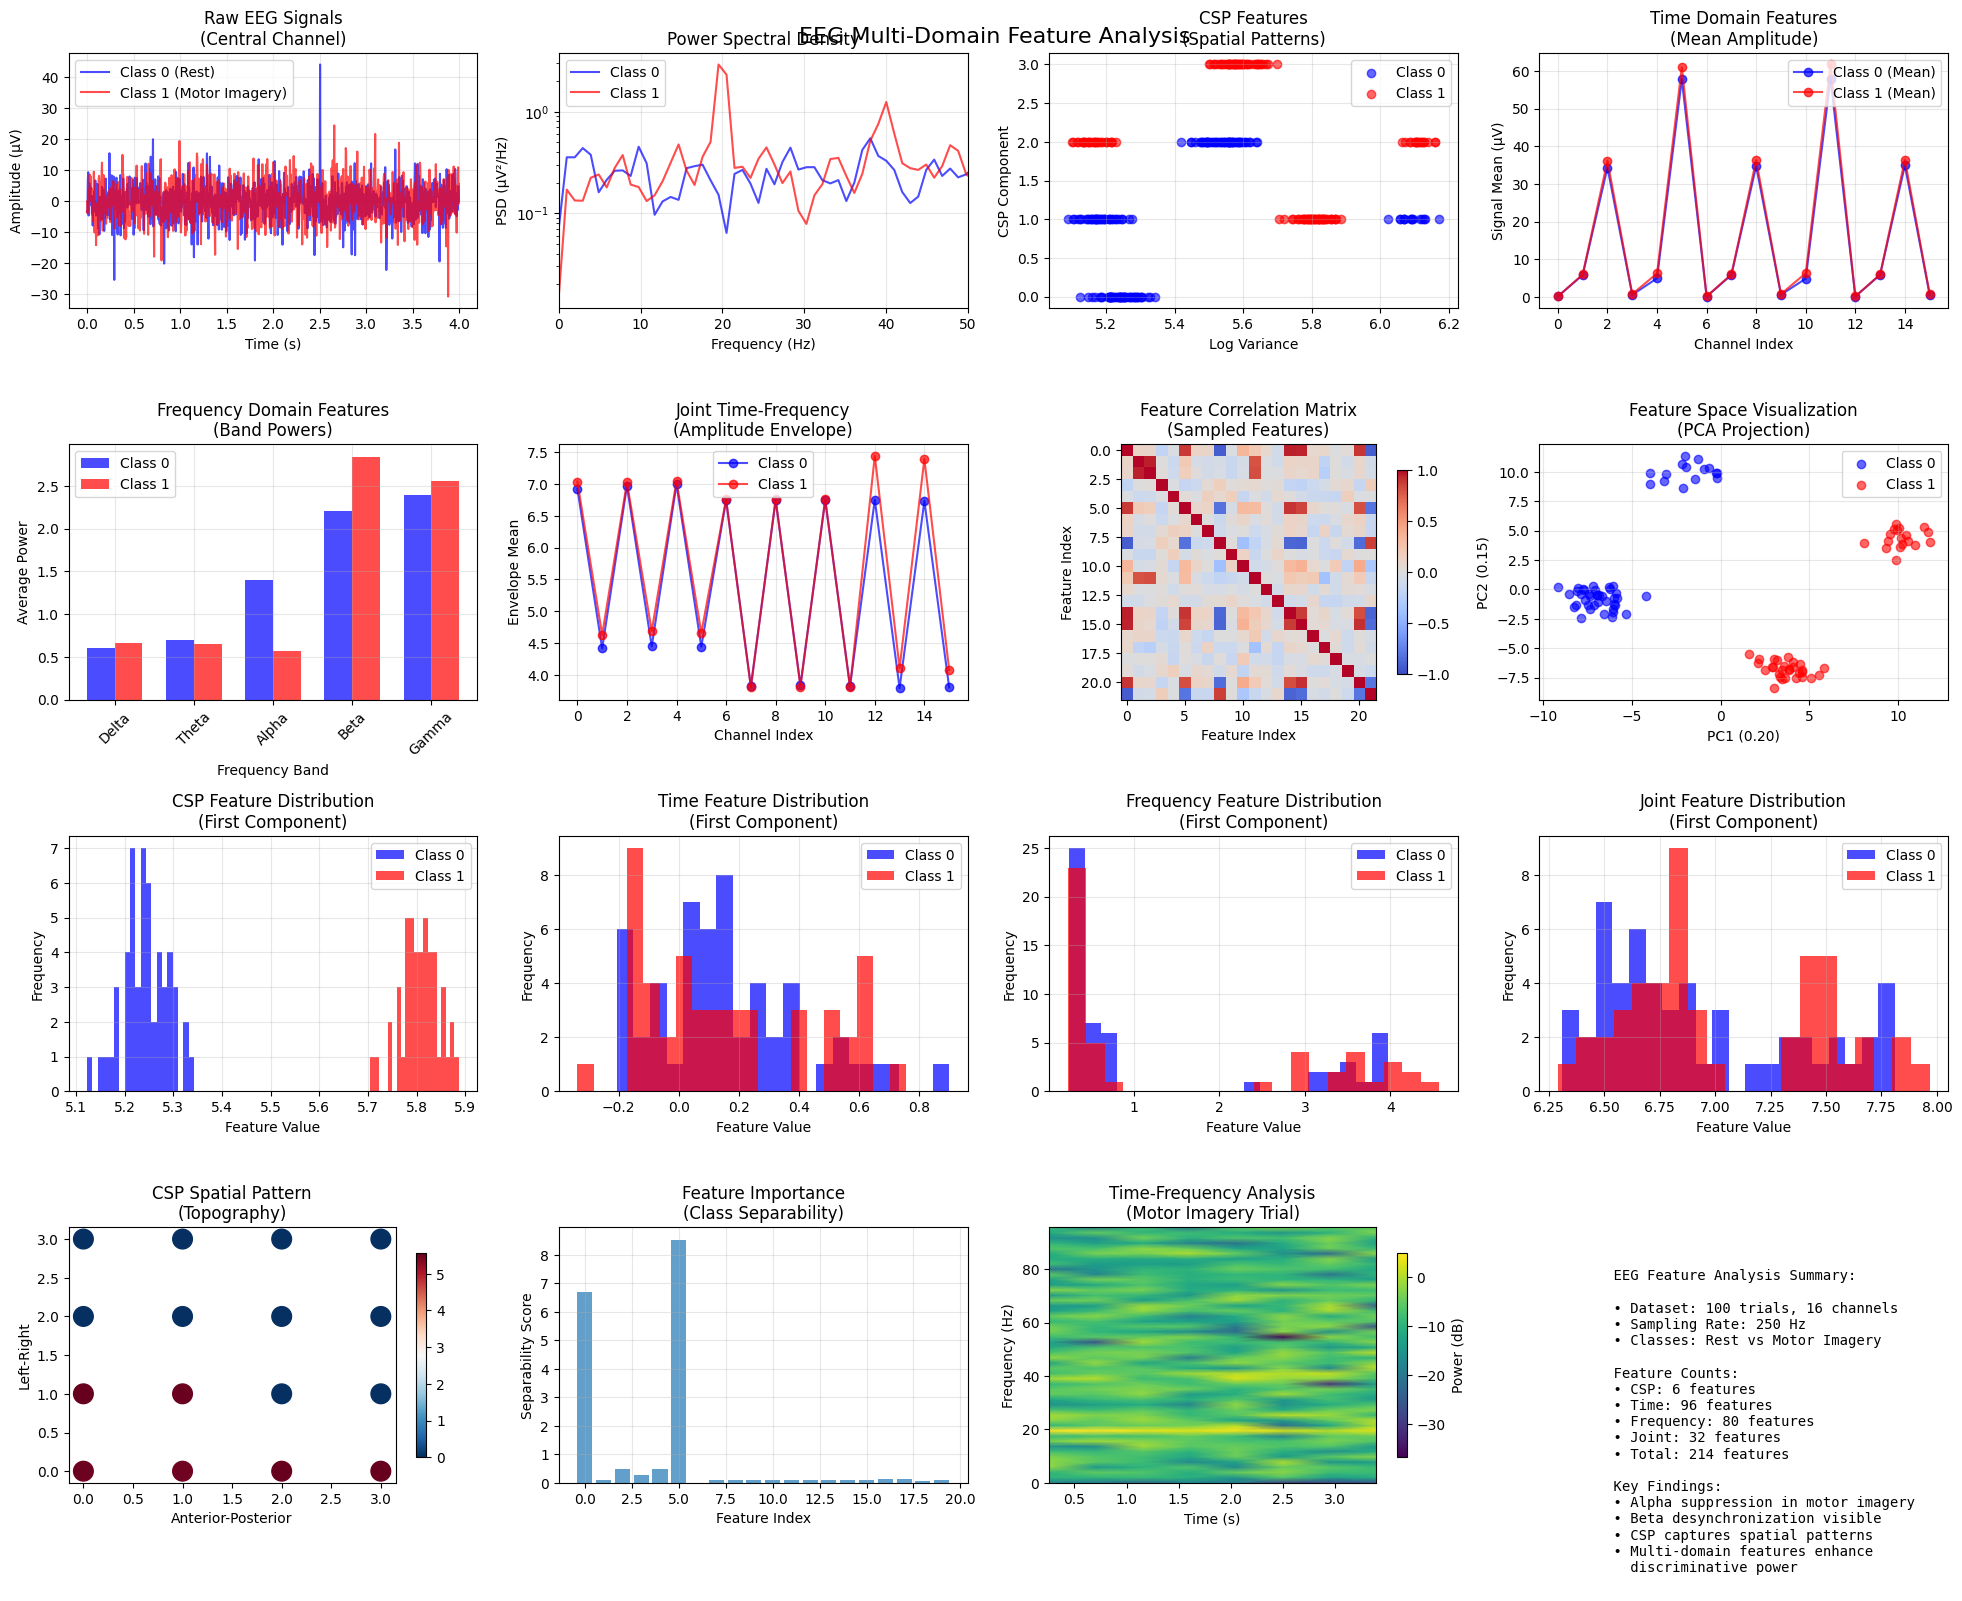


Feature extraction completed!
Total features extracted: 214


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, hilbert
from scipy.stats import skew, kurtosis
from scipy.linalg import eigh
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Previous CSPFeatureExtractor class (simplified for plotting)
class CSPFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=6, freq_bands=None, sfreq=250):
        self.n_components = n_components
        self.sfreq = sfreq
        self.W = None
        self.freq_bands = freq_bands or {
            'delta': (0.5, 4), 'theta': (4, 8), 'alpha': (8, 13),
            'beta': (13, 30), 'gamma': (30, 50)
        }
        self.feature_names = []
    
    def fit(self, X, y):
        X_class0, X_class1 = X[y == 0], X[y == 1]
        C0, C1 = self._covariance(X_class0), self._covariance(X_class1)
        
        reg = 1e-6
        C_total = C0 + C1 + reg * np.eye(C0.shape[0])
        eigenvals, eigenvecs = eigh(C1, C_total)
        
        idx = np.argsort(eigenvals)[::-1]
        eigenvecs = eigenvecs[:, idx]
        
        self.W = np.concatenate([
            eigenvecs[:, :self.n_components//2].T,
            eigenvecs[:, -self.n_components//2:].T
        ])
        return self
    
    def _covariance(self, X):
        n_trials, n_channels, n_samples = X.shape
        cov = np.zeros((n_channels, n_channels))
        for trial in range(n_trials):
            trial_cov = np.cov(X[trial])
            cov += trial_cov / np.trace(trial_cov)
        return cov / n_trials
    
    def transform(self, X):
        csp_features = self.extract_csp_features(X)
        time_features = self.extract_time_features(X)
        freq_features = self.extract_frequency_features(X)
        joint_features = self.extract_joint_features(X)
        
        return {
            'csp': csp_features,
            'time': time_features,
            'frequency': freq_features,
            'joint': joint_features,
            'combined': np.concatenate([csp_features, time_features, freq_features, joint_features], axis=1)
        }
    
    def extract_csp_features(self, X):
        n_trials = X.shape[0]
        csp_features = np.zeros((n_trials, self.n_components))
        for trial in range(n_trials):
            filtered = np.dot(self.W, X[trial])
            csp_features[trial] = np.log(np.var(filtered, axis=1))
        return csp_features
    
    def extract_time_features(self, X):
        n_trials, n_channels, n_samples = X.shape
        features = []
        
        for trial in range(n_trials):
            trial_features = []
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                trial_features.extend([
                    np.mean(signal), np.std(signal), np.var(signal),
                    skew(signal), kurtosis(signal), np.ptp(signal)
                ])
            features.append(trial_features)
        return np.array(features)
    
    def extract_frequency_features(self, X):
        n_trials, n_channels, n_samples = X.shape
        features = []
        
        for trial in range(n_trials):
            trial_features = []
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                freqs, psd = welch(signal, fs=self.sfreq, nperseg=min(128, n_samples//4))
                
                for band_name, (low, high) in self.freq_bands.items():
                    band_power = np.sum(psd[(freqs >= low) & (freqs <= high)])
                    trial_features.append(band_power)
                    
            features.append(trial_features)
        return np.array(features)
    
    def extract_joint_features(self, X):
        n_trials, n_channels, n_samples = X.shape
        features = []
        
        for trial in range(n_trials):
            trial_features = []
            for ch in range(n_channels):
                signal = X[trial, ch, :]
                analytic_signal = hilbert(signal)
                amplitude_envelope = np.abs(analytic_signal)
                
                trial_features.extend([
                    np.mean(amplitude_envelope),
                    np.std(amplitude_envelope)
                ])
            features.append(trial_features)
        return np.array(features)

def generate_realistic_eeg_data():
    """Generate realistic EEG data with motor imagery patterns"""
    n_trials = 100
    n_channels = 16
    n_samples = 1000
    sfreq = 250
    
    np.random.seed(42)
    X = np.random.randn(n_trials, n_channels, n_samples) * 5
    y = np.random.randint(0, 2, n_trials)
    
    t = np.arange(n_samples) / sfreq
    
    # Add realistic EEG patterns
    for i, label in enumerate(y):
        if label == 0:  # Rest condition
            # Alpha rhythm (8-12 Hz) in occipital channels
            alpha = 8 * np.sin(2 * np.pi * 10 * t) * np.exp(-t/2)
            X[i, 12:16, :] += alpha
            
        else:  # Motor imagery condition
            # Beta desynchronization (13-30 Hz) in motor channels
            beta_suppression = -3 * np.sin(2 * np.pi * 20 * t)
            X[i, 6:10, :] += beta_suppression
            
            # Gamma increase (30-50 Hz) during imagery
            gamma = 2 * np.sin(2 * np.pi * 40 * t) * (t > 1) * (t < 3)
            X[i, 6:10, :] += gamma
    
    # Add realistic noise and artifacts
    for i in range(n_trials):
        # Eye blink artifacts (frontal channels)
        if np.random.random() < 0.3:  # 30% chance of blink
            blink_time = np.random.randint(100, 800)
            blink = 50 * np.exp(-np.arange(50)**2/100)
            X[i, 0:3, blink_time:blink_time+50] += blink
        
        # Muscle artifacts
        muscle_burst = np.random.randn(n_channels, n_samples) * 10
        muscle_mask = np.random.random((n_channels, n_samples)) < 0.05
        X[i] += muscle_burst * muscle_mask
    
    return X, y, sfreq

def plot_feature_analysis(X, y, features, sfreq):
    """Create comprehensive feature visualization"""
    
    plt.style.use('default')
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Raw EEG signals comparison
    ax1 = plt.subplot(4, 4, 1)
    class0_idx = np.where(y == 0)[0][0]
    class1_idx = np.where(y == 1)[0][0]
    
    t = np.arange(X.shape[2]) / sfreq
    plt.plot(t, X[class0_idx, 8, :], 'b-', alpha=0.7, label='Class 0 (Rest)')
    plt.plot(t, X[class1_idx, 8, :], 'r-', alpha=0.7, label='Class 1 (Motor Imagery)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (µV)')
    plt.title('Raw EEG Signals\n(Central Channel)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Power Spectral Density
    ax2 = plt.subplot(4, 4, 2)
    from scipy.signal import welch
    
    f0, psd0 = welch(X[class0_idx, 8, :], fs=sfreq, nperseg=256)
    f1, psd1 = welch(X[class1_idx, 8, :], fs=sfreq, nperseg=256)
    
    plt.semilogy(f0, psd0, 'b-', alpha=0.7, label='Class 0')
    plt.semilogy(f1, psd1, 'r-', alpha=0.7, label='Class 1')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('PSD (µV²/Hz)')
    plt.title('Power Spectral Density')
    plt.xlim(0, 50)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. CSP Features
    ax3 = plt.subplot(4, 4, 3)
    csp_data = features['csp']
    
    for i in range(min(3, csp_data.shape[1])):
        plt.scatter(csp_data[y==0, i], np.zeros(np.sum(y==0)) + i, 
                   alpha=0.6, c='blue', label=f'Class 0' if i==0 else "")
        plt.scatter(csp_data[y==1, i], np.ones(np.sum(y==1)) + i, 
                   alpha=0.6, c='red', label=f'Class 1' if i==0 else "")
    
    plt.ylabel('CSP Component')
    plt.xlabel('Log Variance')
    plt.title('CSP Features\n(Spatial Patterns)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 4. Time Domain Features (Statistics)
    ax4 = plt.subplot(4, 4, 4)
    time_data = features['time']
    
    # Select subset of time features for visualization
    n_ch = 16
    mean_features = time_data[:, :n_ch]  # Mean values per channel
    
    class0_means = np.mean(mean_features[y==0], axis=0)
    class1_means = np.mean(mean_features[y==1], axis=0)
    
    channels = np.arange(n_ch)
    plt.plot(channels, class0_means, 'bo-', alpha=0.7, label='Class 0 (Mean)')
    plt.plot(channels, class1_means, 'ro-', alpha=0.7, label='Class 1 (Mean)')
    plt.xlabel('Channel Index')
    plt.ylabel('Signal Mean (µV)')
    plt.title('Time Domain Features\n(Mean Amplitude)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 5. Frequency Band Powers
    ax5 = plt.subplot(4, 4, 5)
    freq_data = features['frequency']
    
    band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    n_bands = len(band_names)
    n_ch = freq_data.shape[1] // n_bands
    
    # Average across channels for each band
    band_powers_c0 = []
    band_powers_c1 = []
    
    for band_idx in range(n_bands):
        band_features = freq_data[:, band_idx::n_bands]
        band_power_c0 = np.mean(band_features[y==0])
        band_power_c1 = np.mean(band_features[y==1])
        band_powers_c0.append(band_power_c0)
        band_powers_c1.append(band_power_c1)
    
    x_pos = np.arange(n_bands)
    width = 0.35
    
    plt.bar(x_pos - width/2, band_powers_c0, width, alpha=0.7, color='blue', label='Class 0')
    plt.bar(x_pos + width/2, band_powers_c1, width, alpha=0.7, color='red', label='Class 1')
    plt.xlabel('Frequency Band')
    plt.ylabel('Average Power')
    plt.title('Frequency Domain Features\n(Band Powers)')
    plt.xticks(x_pos, band_names, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 6. Joint Time-Frequency Features (Amplitude Envelope)
    ax6 = plt.subplot(4, 4, 6)
    joint_data = features['joint']
    
    # Amplitude envelope features
    envelope_means = joint_data[:, :n_ch]  # First n_ch features are envelope means
    
    class0_env = np.mean(envelope_means[y==0], axis=0)
    class1_env = np.mean(envelope_means[y==1], axis=0)
    
    plt.plot(channels, class0_env, 'bo-', alpha=0.7, label='Class 0')
    plt.plot(channels, class1_env, 'ro-', alpha=0.7, label='Class 1')
    plt.xlabel('Channel Index')
    plt.ylabel('Envelope Mean')
    plt.title('Joint Time-Frequency\n(Amplitude Envelope)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. Feature Correlation Matrix
    ax7 = plt.subplot(4, 4, 7)
    combined_features = features['combined']
    
    # Sample subset of features for correlation
    sample_features = combined_features[:, ::10]  # Every 10th feature
    corr_matrix = np.corrcoef(sample_features.T)
    
    im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, shrink=0.8)
    plt.title('Feature Correlation Matrix\n(Sampled Features)')
    plt.xlabel('Feature Index')
    plt.ylabel('Feature Index')
    
    # 8. Class Separability (PCA)
    ax8 = plt.subplot(4, 4, 8)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(combined_features)
    
    pca = PCA(n_components=2)
    pca_features = pca.fit_transform(scaled_features)
    
    plt.scatter(pca_features[y==0, 0], pca_features[y==0, 1], 
               alpha=0.6, c='blue', label='Class 0')
    plt.scatter(pca_features[y==1, 0], pca_features[y==1, 1], 
               alpha=0.6, c='red', label='Class 1')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    plt.title('Feature Space Visualization\n(PCA Projection)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 9-12. Individual feature distributions
    feature_types = ['CSP', 'Time', 'Frequency', 'Joint']
    feature_data_list = [features['csp'], features['time'], features['frequency'], features['joint']]
    
    for i, (feat_type, feat_data) in enumerate(zip(feature_types, feature_data_list)):
        ax = plt.subplot(4, 4, 9+i)
        
        # Select first feature for distribution plot
        feature_values = feat_data[:, 0]
        
        plt.hist(feature_values[y==0], alpha=0.7, color='blue', label='Class 0', bins=20)
        plt.hist(feature_values[y==1], alpha=0.7, color='red', label='Class 1', bins=20)
        plt.xlabel('Feature Value')
        plt.ylabel('Frequency')
        plt.title(f'{feat_type} Feature Distribution\n(First Component)')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # 13. Topographical representation (simulated)
    ax13 = plt.subplot(4, 4, 13)
    
    # Simulate channel positions (simplified 4x4 grid)
    channel_pos = np.array([[i%4, i//4] for i in range(16)])
    
    # Use CSP pattern strength as topography
    csp_strength = np.mean(np.abs(features['csp']), axis=0)
    if len(csp_strength) >= 16:
        topo_values = csp_strength[:16]
    else:
        topo_values = np.pad(csp_strength, (0, 16-len(csp_strength)), 'constant')
    
    scatter = plt.scatter(channel_pos[:, 0], channel_pos[:, 1], 
                         c=topo_values, s=200, cmap='RdBu_r')
    plt.colorbar(scatter, shrink=0.8)
    plt.title('CSP Spatial Pattern\n(Topography)')
    plt.xlabel('Anterior-Posterior')
    plt.ylabel('Left-Right')
    
    # 14. Feature importance (simulated)
    ax14 = plt.subplot(4, 4, 14)
    
    # Calculate feature separability (simple metric)
    combined_features = features['combined']
    feature_separability = []
    
    for feat_idx in range(min(20, combined_features.shape[1])):
        class0_mean = np.mean(combined_features[y==0, feat_idx])
        class1_mean = np.mean(combined_features[y==1, feat_idx])
        class0_std = np.std(combined_features[y==0, feat_idx])
        class1_std = np.std(combined_features[y==1, feat_idx])
        
        # Simple separability metric
        separability = abs(class0_mean - class1_mean) / (class0_std + class1_std + 1e-10)
        feature_separability.append(separability)
    
    plt.bar(range(len(feature_separability)), feature_separability, alpha=0.7)
    plt.xlabel('Feature Index')
    plt.ylabel('Separability Score')
    plt.title('Feature Importance\n(Class Separability)')
    plt.grid(True, alpha=0.3)
    
    # 15. Time-frequency representation
    ax15 = plt.subplot(4, 4, 15)
    
    # Create spectrogram for one trial
    from scipy.signal import spectrogram
    
    f, t_spec, Sxx = spectrogram(X[class1_idx, 8, :], fs=sfreq, nperseg=128)
    
    plt.pcolormesh(t_spec, f[:50], 10*np.log10(Sxx[:50, :]), shading='gouraud')
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.title('Time-Frequency Analysis\n(Motor Imagery Trial)')
    plt.colorbar(shrink=0.8, label='Power (dB)')
    
    # 16. Summary statistics
    ax16 = plt.subplot(4, 4, 16)
    ax16.axis('off')
    
    # Summary text
    summary_text = f"""
    EEG Feature Analysis Summary:
    
    • Dataset: {X.shape[0]} trials, {X.shape[1]} channels
    • Sampling Rate: {sfreq} Hz
    • Classes: Rest vs Motor Imagery
    
    Feature Counts:
    • CSP: {features['csp'].shape[1]} features
    • Time: {features['time'].shape[1]} features  
    • Frequency: {features['frequency'].shape[1]} features
    • Joint: {features['joint'].shape[1]} features
    • Total: {features['combined'].shape[1]} features
    
    Key Findings:
    • Alpha suppression in motor imagery
    • Beta desynchronization visible
    • CSP captures spatial patterns
    • Multi-domain features enhance
      discriminative power
    """
    
    ax16.text(0.1, 0.9, summary_text, transform=ax16.transAxes, 
              fontsize=10, verticalalignment='top', fontfamily='monospace')
    
    plt.tight_layout()
    plt.suptitle('EEG Multi-Domain Feature Analysis', fontsize=16, y=0.98)
    plt.show()
    
    return fig

# Main execution
def main():
    print("Generating realistic EEG data...")
    X, y, sfreq = generate_realistic_eeg_data()
    
    print("Extracting features...")
    extractor = CSPFeatureExtractor(n_components=6, sfreq=sfreq)
    extractor.fit(X, y)
    features = extractor.transform(X)
    
    print("Creating visualizations...")
    fig = plot_feature_analysis(X, y, features, sfreq)
    
    print("\nFeature extraction completed!")
    print(f"Total features extracted: {features['combined'].shape[1]}")
    
    return X, y, features, extractor

if __name__ == "__main__":
    X, y, features, extractor = main()